<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [ ]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
df.columns = ['Date', 'Passengers']
df.head()

,Date,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
df.shape

(144, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
# Convert Date to datetime and set index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [ ]:
df.head()

,Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
# Check for missing values
print(df.isnull().sum())

Passengers    0
dtype: int64


In [ ]:
# Fill missing values using forward fill
df = df.fillna(method='ffill')

/tmp/ipython-input-1563967903.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
# Detect outliers using Z-score
df['zscore'] = zscore(df['Passengers'])

In [ ]:
# Remove outliers beyond ±3
df = df[df['zscore'].abs() < 3]

In [ ]:
df.head()

,Passengers,zscore
Date,,
1949-01-01,112,-1.407779
1949-02-01,118,-1.357590
1949-03-01,132,-1.240483
1949-04-01,129,-1.265578
1949-05-01,121,-1.332496


In [ ]:
df.shape

(144, 2)

In [ ]:
# Drop zscore column
df.drop(columns='zscore', inplace=True)

In [ ]:
df.shape

(144, 1)

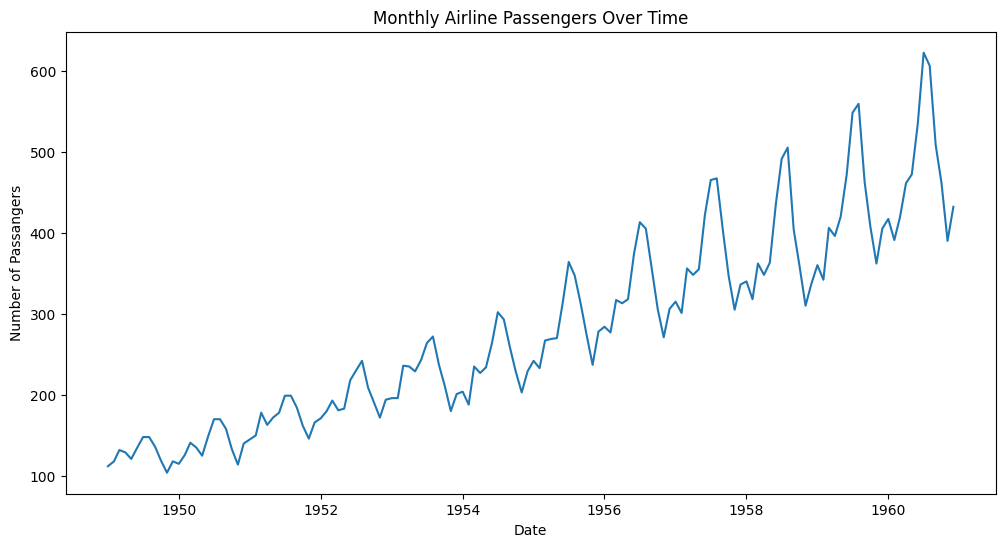

In [ ]:
# Plot the cleaned data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'])
plt.title('Monthly Airline Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passangers')
plt.show()

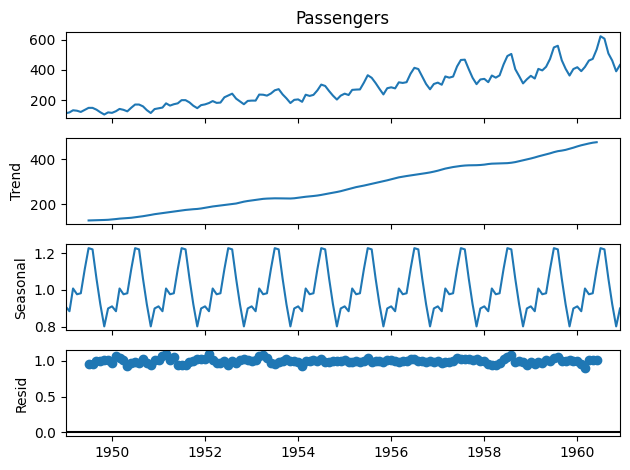

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Multiplicative decomposition (for seasonal data)
result = seasonal_decompose(df['Passengers'], model='multiplicative')

# Plot decomposition
result.plot()
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


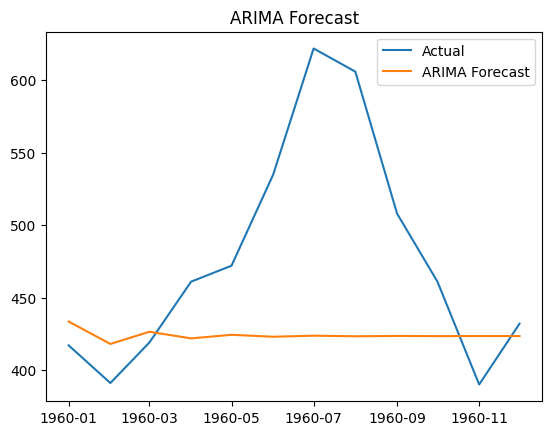

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# p (Autoregressive Part)
# d (Integrated Part)
# q (Moving Average Part)

# Train-test split
train = df.iloc[:-12]
test = df.iloc[-12:]

# Fit ARIMA model
model_arima = ARIMA(train['Passengers'], order=(1, 1, 1))
model_arima_fit = model_arima.fit()

# Forecast next 12 months
forecast_arima = model_arima_fit.forecast(steps=12)

# Plot
plt.plot(test.index, test['Passengers'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


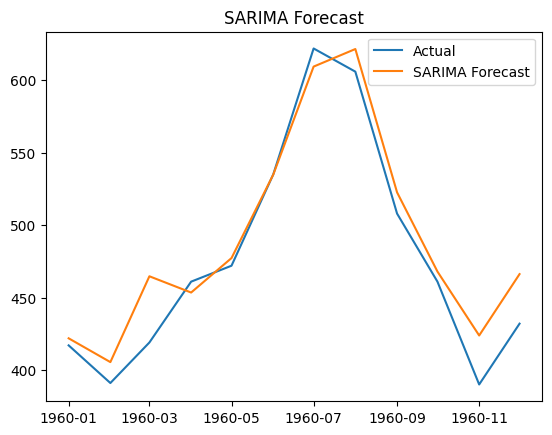

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
model_sarima = SARIMAX(train['Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_sarima_fit = model_sarima.fit()

# Forecast
forecast_sarima = model_sarima_fit.forecast(steps=12)

# Plot
plt.plot(test.index, test['Passengers'], label='Actual')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA Forecast')
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0_j6h0mt/vhl_j_aw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0_j6h0mt/hzzzbe6t.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37504', 'data', 'file=/tmp/tmp0_j6h0mt/vhl_j_aw.json', 'init=/tmp/tmp0_j6h0mt/hzzzbe6t.json', 'output', 'file=/tmp/tmp0_j6h0mt/prophet_model8_dma6n7/prophet_model-20251017030350.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:03:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:03:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/

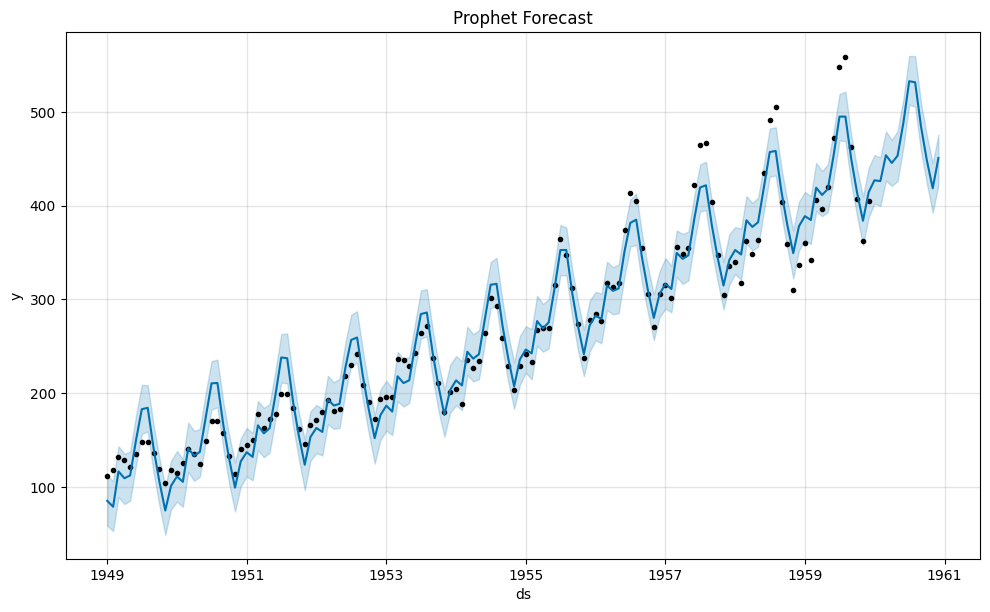

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Prepare data for Prophet
df_prophet = df.reset_index().rename(columns={'Date': 'ds', 'Passengers': 'y'})
train_prophet = df_prophet.iloc[:-12]

# Fit model
model_prophet = Prophet()
model_prophet.fit(train_prophet)

# Create future dataframe
future = model_prophet.make_future_dataframe(periods=12, freq='M')
forecast_prophet = model_prophet.predict(future)

# Plot forecast
model_prophet.plot(forecast_prophet)
plt.title('Prophet Forecast')
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0_j6h0mt/q0bgri2_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0_j6h0mt/6m_7lz_2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24463', 'data', 'file=/tmp/tmp0_j6h0mt/q0bgri2_.json', 'init=/tmp/tmp0_j6h0mt/6m_7lz_2.json', 'output', 'file=/tmp/tmp0_j6h0mt/prophet_modelw3sxc33s/prophet_model-20251017030351.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
03:03:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:03:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages

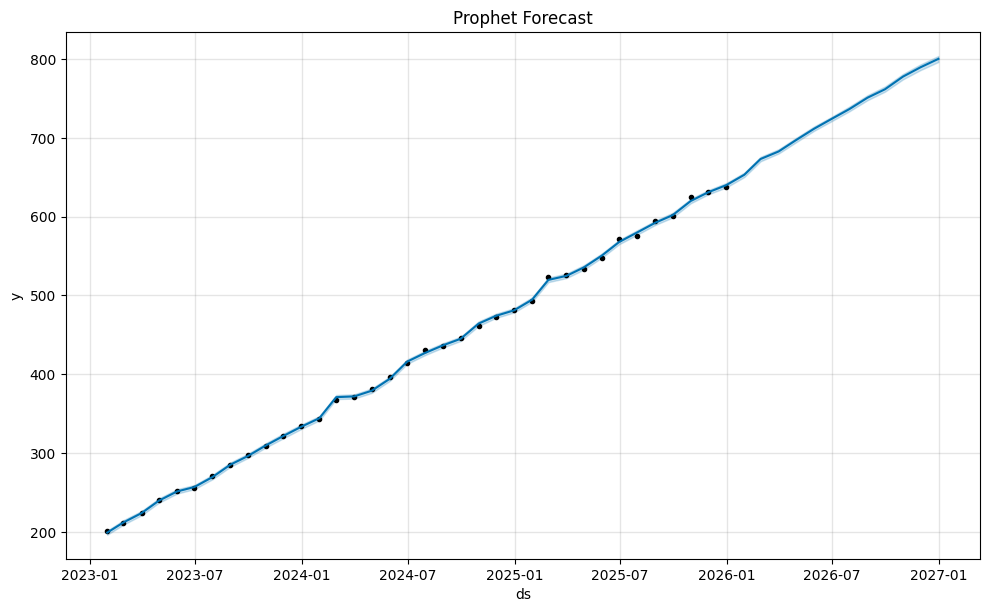

In [ ]:
data = {
    'ds' : pd.date_range(start='2023-01-01', periods=36, freq='ME'),
    'y' : np.linspace(200,641,36) + np.random.randint(-10,10,36)
}

df = pd.DataFrame(data)

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

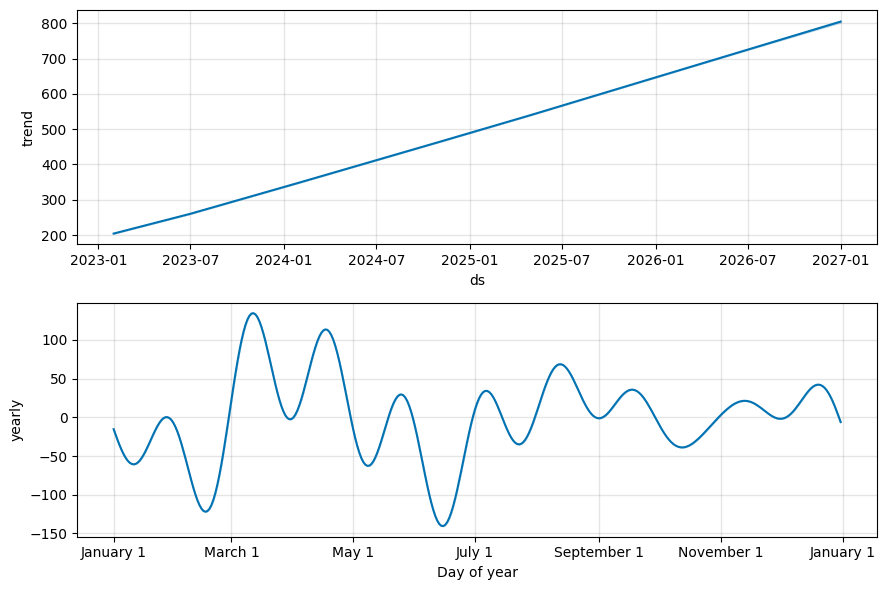

In [ ]:
model.plot_components(forecast)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual test values
y_true = test['Passengers'].values

# Prophet predictions
y_pred_prophet = forecast_prophet.iloc[-12:]['yhat'].values

# Evaluation function
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Run evaluations
evaluate(y_true, forecast_arima.values, "ARIMA")
evaluate(y_true, forecast_sarima.values, "SARIMA")
evaluate(y_true, y_pred_prophet, "Prophet")


ARIMA - MAE: 66.24, RMSE: 91.23
SARIMA - MAE: 16.31, RMSE: 21.18
Prophet - MAE: 33.98, RMSE: 41.51


In [ ]:
y_true

array([417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432])

In [ ]:
y_pred_prophet

array([427.04347034, 426.15675866, 453.8157058 , 445.53046618,
       453.19844829, 488.9065129 , 532.72219721, 531.52962796,
       484.0990709 , 448.65376193, 418.55974527, 450.83066916])

In [ ]:
forecast_arima.values

array([433.45192691, 417.98422101, 426.3931392 , 421.82168526,
       424.30692661, 422.95584123, 423.69035005, 423.29103909,
       423.50812191, 423.39010624, 423.45426469, 423.41938536])

In [ ]:
forecast_sarima.values

array([421.87456491, 405.44522888, 464.70760579, 453.48464977,
       477.28251048, 534.85843205, 609.4857342 , 621.61777347,
       522.64904356, 467.97511524, 423.82579241, 466.21359477])